# Exporting charts

Export a chart by rendering it to image bytes with `chart.render(fmt)`, then write the bytes wherever they need to go — a file, a web page, an HTTP response. Supported formats include SVG, PNG, and JPG.

In [6]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, Volume, Pane, LinePlot
from mplchart.indicators import SMA, RSI, MACD

prices = sample_prices()

## Plot chart with indicators

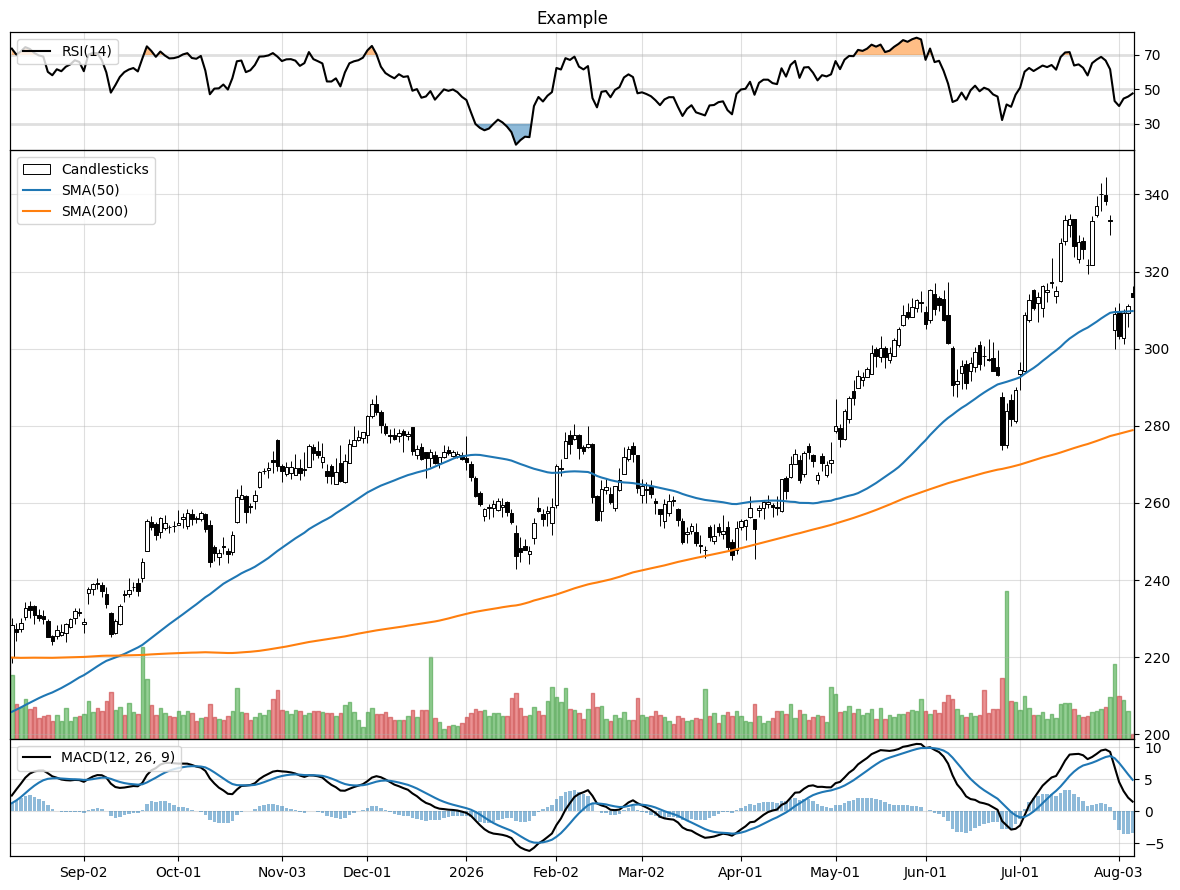

In [7]:
max_bars = 250

chart = Chart(prices, title="Example", max_bars=max_bars).plot(
    Candlesticks(use_bars=False),
    SMA(50),
    SMA(200),
    Volume(),
    Pane("above", yticks=(30, 50, 70)),
    LinePlot(RSI(), overbought=70, oversold=30),
    Pane("below"),
    MACD(),
)

## Render to SVG or PNG

In [8]:
data = chart.render("svg")

print(data[:20] + b"...")


b'<?xml version="1.0" ...'


In [9]:
data = chart.render("png")

print(data[:20] + b"...")

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x04\xb0...'


## Saving to a file

`render` returns bytes and deliberately stops there — writing them is one line with whatever destination you have:

```python
from pathlib import Path

Path("chart.svg").write_bytes(chart.render("svg"))
Path("chart.png").write_bytes(chart.render("png"))
```

The same bytes embed directly in a web response or an HTML `<img>` tag — see the `Chart.render` entry in the API reference for the format and `dpi` options.